Data type: uint8
Min. value: 0
Max value: 247
Dimensiones de la imagen: (275, 500, 3)
Imagen convertida a escala de grises


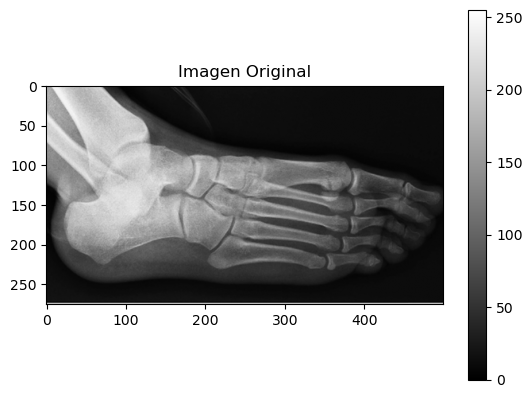

In [1]:
import imageio.v2 as imageio  # lector de imágenes
import numpy as np  # operaciones numéricas
import matplotlib.pyplot as plt  # visualización
import scipy.ndimage as ndi  # procesamiento de imágenes
import matplotlib.ticker as ticker

# ============================================================================
# PARTE 1: CARGAR IMAGEN
# ============================================================================

# 2. Cargamos la radiografía
im = imageio.imread('RXPie.jpg')

# 3. Mostramos información básica de la imagen
print('Data type:', im.dtype)
print('Min. value:', im.min())
print('Max value:', im.max())
print('Dimensiones de la imagen:', im.shape)
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
    print('Imagen convertida a escala de grises')
else:
    im = im.astype(np.uint8)
    print('Imagen ya está en escala de grises')

# 4. Configuramos los valores de ticks (intervalos para la barra de color)
min_val = 0
max_val = np.max(im)
tick_interval = 50
tick_vals = np.arange(min_val, int(max_val) + tick_interval, tick_interval)

# Mostrar la imagen en escala de grises
plt.imshow(im, vmin=0, vmax=255, cmap='gray')
colorbar = plt.colorbar()
colorbar.set_ticks(tick_vals)
plt.title('Imagen Original')
# Renderizar la figura
plt.show()

Forma del histograma: (256,)


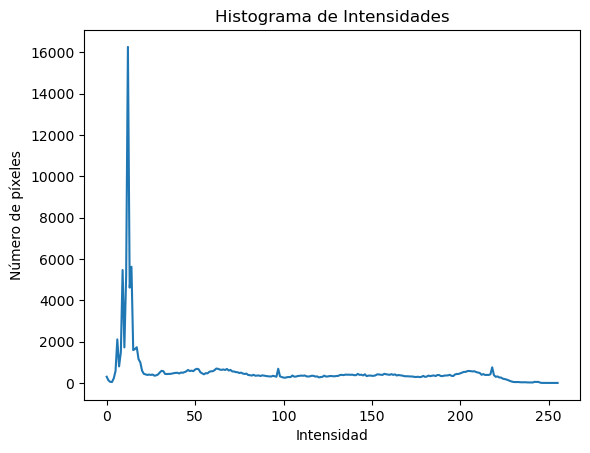

In [2]:
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi

# Create a histogram, binned at each possible value
hist = ndi.histogram(im, min=0, max=255, bins=256)
print('Forma del histograma:', hist.shape)

# Dibujar el Histograma
plt.plot(hist)
plt.xlabel('Intensidad')
plt.ylabel('Número de píxeles')
plt.title('Histograma de Intensidades')
plt.show()

Forma del CDF: (256,)


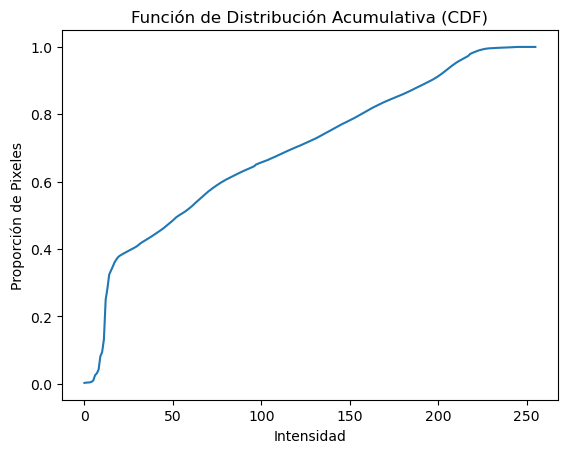

In [3]:
# Create a cumulative distribution function
cdf = hist.cumsum() / hist.sum()
print('Forma del CDF:', cdf.shape)

# Dibujar distribución CDF
plt.plot(cdf)
plt.xlabel('Intensidad')
plt.ylabel('Proporción de Pixeles')
plt.title('Función de Distribución Acumulativa (CDF)')
plt.show()

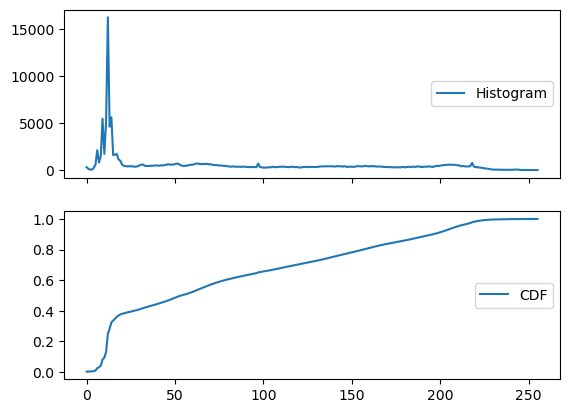

In [4]:
# Plot the histogram and CDF
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(hist, label='Histogram')
axes[1].plot(cdf, label='CDF')
for ax in fig.axes:
    ax.legend(loc='center right')
plt.show()

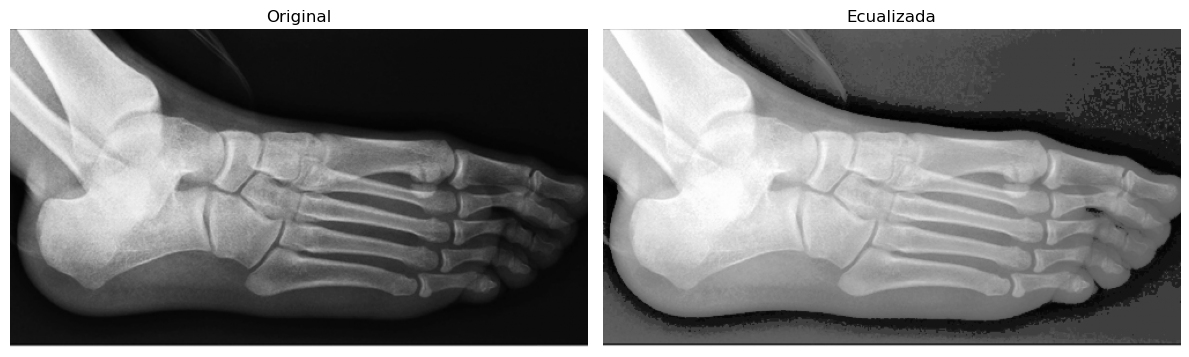

In [5]:
# Crear imagen ecualizada
im_ecualizada = (cdf[im] * 255).astype(np.uint8)

# Mostrar comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(im_ecualizada, cmap='gray')
axes[1].set_title('Ecualizada')
axes[1].axis('off')
plt.tight_layout()
plt.show()

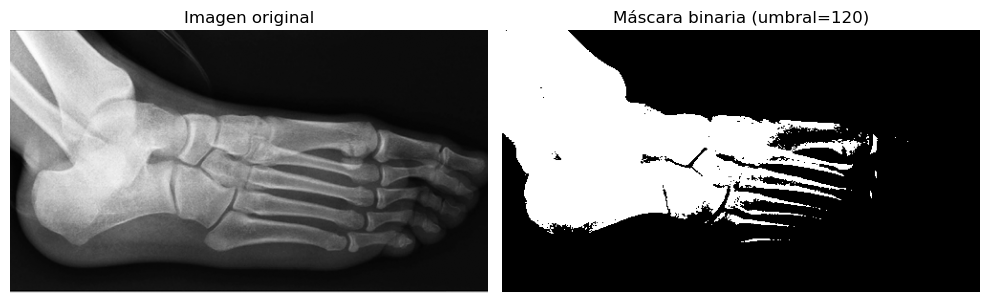

In [6]:
# Definimos un umbral (ajústalo según tu imagen)
umbral = 120

# Crear la máscara binaria: 1 si el valor del píxel es mayor al umbral
mask = im > umbral

# Mostrar imagen original y máscara
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Máscara binaria (umbral={umbral})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

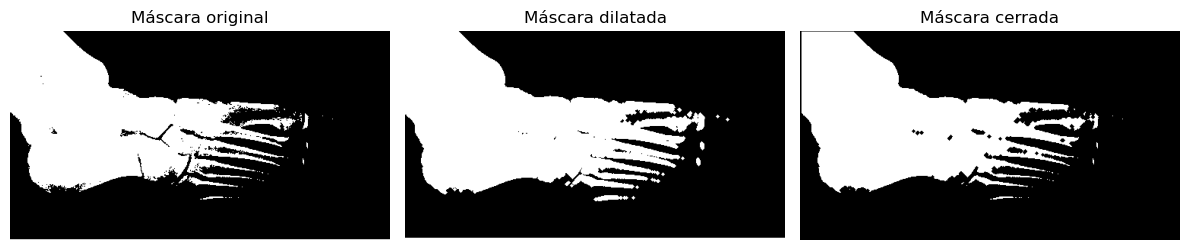

In [7]:
# Dilatación (agranda las regiones blancas)
mask_dilated = ndi.binary_dilation(mask, iterations=2)

# Cierre (rellena huecos pequeños)
mask_closed = ndi.binary_closing(mask, iterations=2)

# Mostrar comparación
fig, axes = plt.subplots(1, 3, figsize=(12,5))
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Máscara original')
axes[0].axis('off')

axes[1].imshow(mask_dilated, cmap='gray')
axes[1].set_title('Máscara dilatada')
axes[1].axis('off')

axes[2].imshow(mask_closed, cmap='gray')
axes[2].set_title('Máscara cerrada')
axes[2].axis('off')

plt.tight_layout()
plt.show()

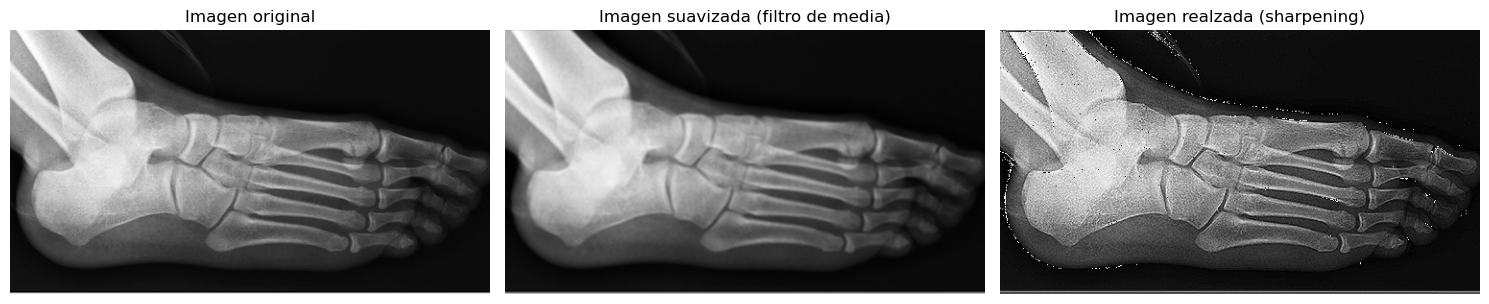

In [9]:
# Kernel de suavizado (media 3x3)
kernel_media = np.ones((3,3)) / 9.0

# Aplicar convolución (suavizado)
imagen_suavizada = ndi.convolve(im, kernel_media)

# Kernel de realce (sharpening)
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])

# Aplicar convolución (realce)
imagen_realzada = ndi.convolve(im, kernel_sharp)

# Mostrar comparaciones
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(imagen_suavizada, cmap='gray')
axes[1].set_title('Imagen suavizada (filtro de media)')
axes[1].axis('off')
    
axes[2].imshow(imagen_realzada, cmap='gray')
axes[2].set_title('Imagen realzada (sharpening)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# ANÁLISIS Y DISCUSIÓN

## 1. ¿Qué efecto tuvo la dilatación sobre la máscara?

La dilatación aumentó el tamaño de las regiones blancas, permitiendo resaltar estructuras. Los píxeles blancos se expandieron hacia el exterior, conectando regiones que estaban cercanas pero separadas. Esto es útil para:
- Cerrar huecos pequeños en las estructuras
- Conectar fragmentos que deberían ser una sola región
- Hacer más evidentes las estructuras anatómicas (huesos del pie)

## 2. ¿Cómo cambió la imagen después del cierre?

El cierre rellenó huecos pequeños, haciendo las áreas más uniformes. A diferencia de la simple dilatación, el cierre (dilatación seguida de erosión) mantiene aproximadamente el tamaño original de las estructuras, pero elimina:
- Pequeños agujeros internos
- Discontinuidades en regiones que deberían ser continuas
- Ruido negro dentro de estructuras blancas

El resultado son máscaras más limpias y homogéneas, ideales para análisis posterior.

## 3. ¿Qué diferencias se observan entre el filtro de media y el de sharpening?

**FILTRO DE MEDIA (Suavizado):**
- El filtro de media suaviza la imagen, reduciendo el ruido pero perdiendo detalle.
- Reduce la variabilidad entre píxeles vecinos.
- Los bordes se vuelven menos definidos y más difusos.
- Es útil como preprocesamiento antes de aplicar algoritmos de detección.

**FILTRO DE SHARPENING (Realce):**
- El filtro de realce aumenta el contraste de los bordes, mejorando la visibilidad.
- Exagera las diferencias entre píxeles vecinos.
- Los bordes se vuelven más nítidos y definidos.
- Puede amplificar el ruido existente en la imagen.

## 4. ¿Qué importancia podrían tener estas técnicas en imágenes médicas reales?

Estas técnicas permiten:

1. **Resaltar estructuras anatómicas**: Mejorar la visualización de huesos, órganos y tejidos.
2. **Limpiar ruido**: Eliminar artefactos de la adquisición de imágenes.
3. **Mejorar el diagnóstico visual**: Aumentar el contraste para identificar lesiones sutiles como fracturas.
4. **Segmentación automática**: Separar automáticamente diferentes tejidos.
5. **Aplicaciones específicas**: 
   - Detección de fracturas en huesos
   - Análisis de densidad ósea para osteoporosis
   - Planificación quirúrgica asistida por computadora
   - Sistemas de diagnóstico asistido por IA (CAD)

**Impacto clínico**: Estas técnicas son fundamentales en la radiología moderna y forman la base de muchos sistemas automatizados de diagnóstico.

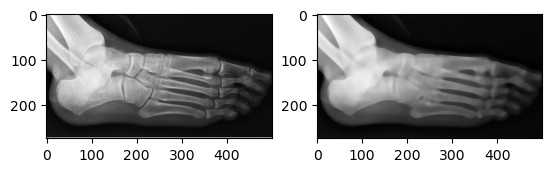

In [12]:
import imageio.v2 as imageio
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import numpy as np
im = imageio.imread('RXPie.jpg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)
# Aplicando filtro de mediana
im_filtrada = ndi.median_filter(im, size=10)
# Graficamos y visualizamos
fig, axes = plt.subplots(1,2)
axes[0].imshow(im, cmap='gray')
axes[1].imshow(im_filtrada, cmap='gray')
plt.show()

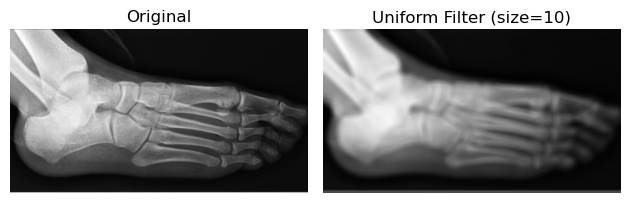

In [13]:
# Aplicando filtro UNIFORM (promedio)
im_uniform = ndi.uniform_filter(im, size=10)

# Graficamos y visualizamos
fig, axes = plt.subplots(1,2)
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(im_uniform, cmap='gray')
axes[1].set_title('Uniform Filter (size=10)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


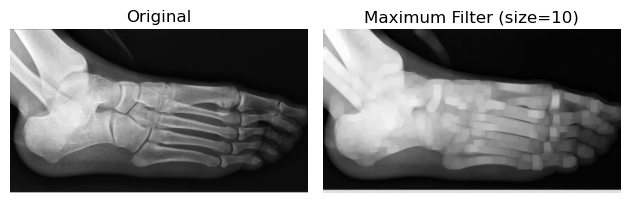

In [14]:
# Aplicando filtro MAXIMUM
im_maximum = ndi.maximum_filter(im, size=10)

# Graficamos y visualizamos
fig, axes = plt.subplots(1,2)
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(im_maximum, cmap='gray')
axes[1].set_title('Maximum Filter (size=10)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

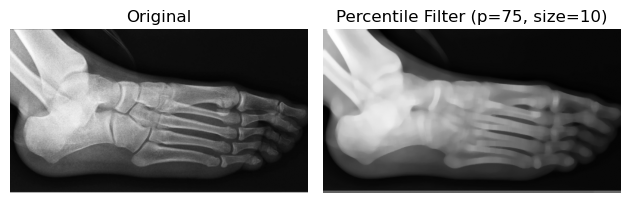

In [15]:
# Aplicando filtro PERCENTILE (percentil 75)
im_percentile = ndi.percentile_filter(im, percentile=75, size=10)

# Graficamos y visualizamos
fig, axes = plt.subplots(1,2)
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(im_percentile, cmap='gray')
axes[1].set_title('Percentile Filter (p=75, size=10)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

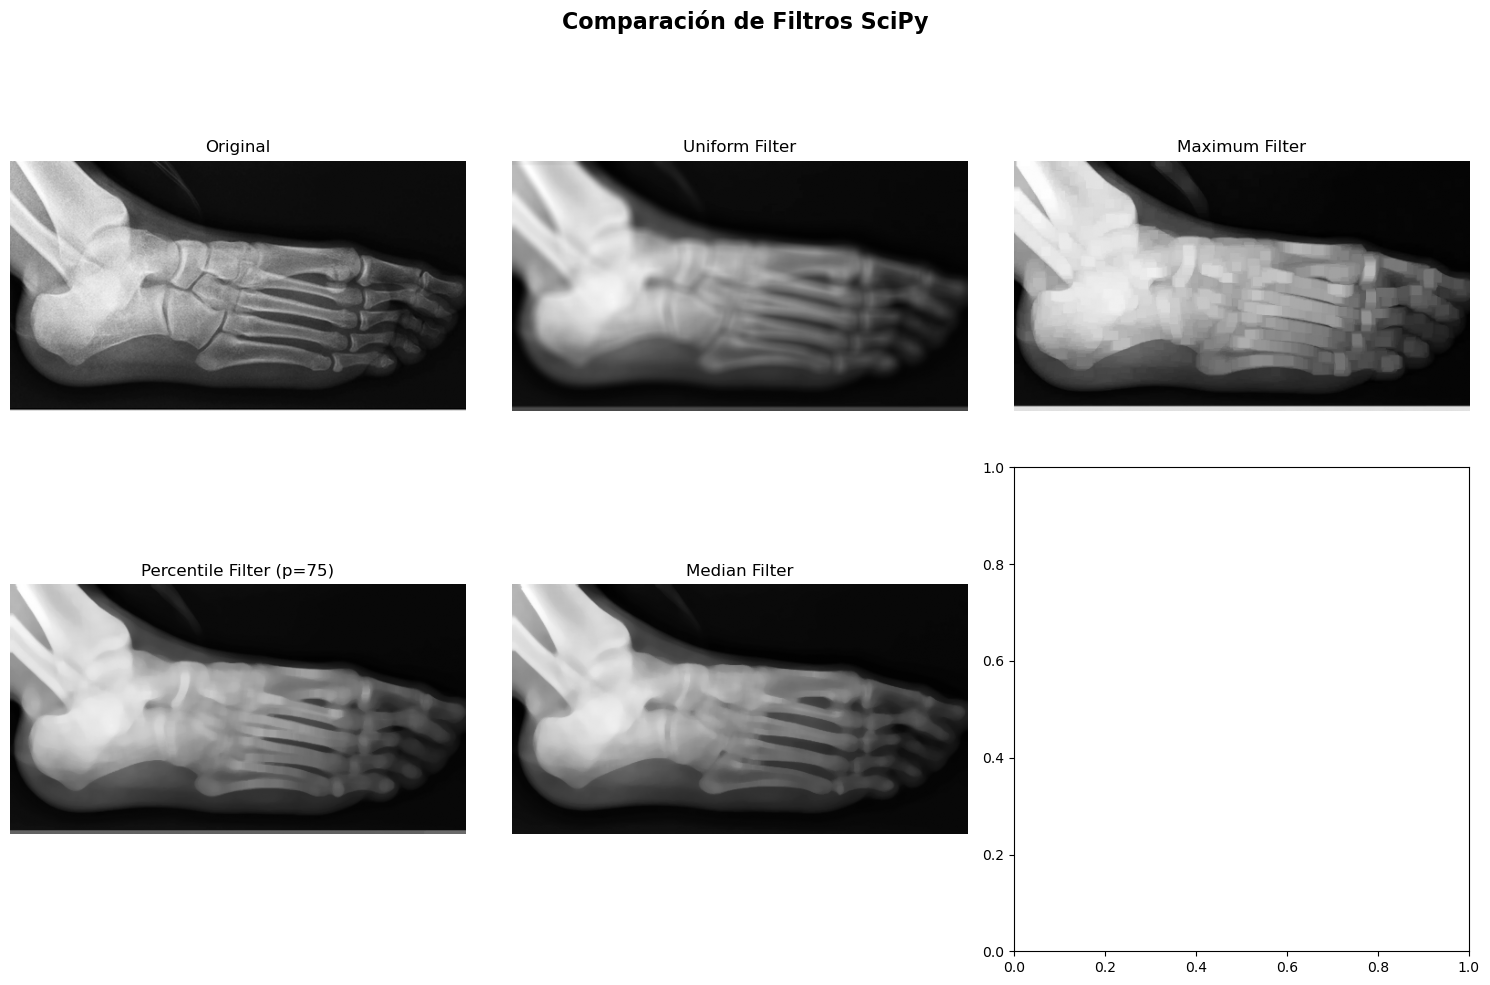

In [17]:
# Crear todas las versiones filtradas
im_uniform = ndi.uniform_filter(im, size=10)
im_maximum = ndi.maximum_filter(im, size=10)
im_percentile = ndi.percentile_filter(im, percentile=75, size=10)
im_median = ndi.median_filter(im, size=10)

# Comparación de todos los filtros
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(im, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(im_uniform, cmap='gray')
axes[0, 1].set_title('Uniform Filter')
axes[0, 1].axis('off')

axes[0, 2].imshow(im_maximum, cmap='gray')
axes[0, 2].set_title('Maximum Filter')
axes[0, 2].axis('off')

axes[1, 0].imshow(im_percentile, cmap='gray')
axes[1, 0].set_title('Percentile Filter (p=75)')
axes[1, 0].axis('off')

axes[1, 1].imshow(im_median, cmap='gray')
axes[1, 1].set_title('Median Filter')
axes[1, 1].axis('off')

plt.suptitle('Comparación de Filtros SciPy', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

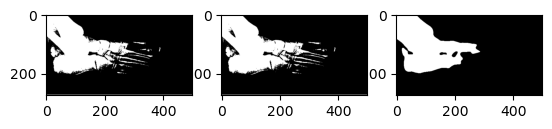

In [27]:
m = imageio.imread('RXPie.jpg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)
# Smooth "im" with Gaussian filters
im_s1 = ndi.gaussian_filter(im, sigma=0.1)
im_s3 = ndi.gaussian_filter(im, sigma=5)
# Draw bone masks of each image
fig, axes = plt.subplots(1,3)
axes[0].imshow(im >= 145, cmap='gray')
axes[1].imshow(im_s1 >= 145, cmap='gray')
axes[2].imshow(im_s3 >= 145, cmap='gray')
plt.show()

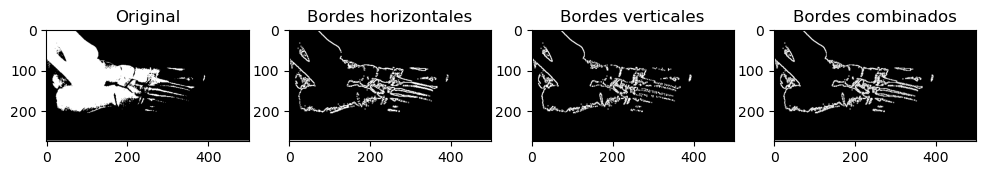

In [29]:
# Importamos las librerías necesarias
import imageio.v2 as imageio # lector de imágenes
import numpy as np # operaciones numéricas
import matplotlib.pyplot as plt # visualización
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi
im = imageio.imread('RXPie.jpg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)

hist = ndi.histogram(im, min=0, max=255, bins=256)
cdf = hist.cumsum() / hist.sum()
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
# Create bone mask
mask_bone = im_ecualizada >=196
# Definir kernels
Kx = np.array([[-1,-1,-1],[0,0,0],[1,1,1]]) # horizontal
Ky = np.array([[-1,0,1],[-1,0,1],[-1,0,1]]) # vertical
# Aplicar convoluciones
Ix = ndi.convolve(mask_bone, Kx)
Iy = ndi.convolve(mask_bone, Ky)
# Magnitud del gradiente
bordes = np.sqrt(np.square(Ix) + np.square(Iy))
# Mostrar
fig, axes = plt.subplots(1,4,figsize=(12,4))
axes[0].imshow(mask_bone, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(Ix, cmap='gray'); axes[1].set_title('Bordes horizontales')
axes[2].imshow(Iy, cmap='gray'); axes[2].set_title('Bordes verticales')
axes[3].imshow(bordes, cmap='gray'); axes[3].set_title('Bordes combinados')
plt.show()

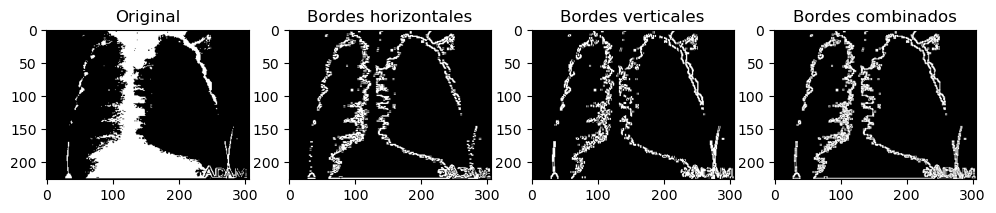

In [31]:
# Importamos las librerías necesarias
import imageio.v2 as imageio # lector de imágenes
import numpy as np # operaciones numéricas
import matplotlib.pyplot as plt # visualización
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi
im = imageio.imread('RXTorax.jpg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)

hist = ndi.histogram(im, min=0, max=255, bins=256)
cdf = hist.cumsum() / hist.sum()
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
# Create bone mask
mask_bone = im_ecualizada >=196
# Definir kernels
Kx = np.array([[-1,-1,-1],[0,0,0],[1,1,1]]) # horizontal
Ky = np.array([[-1,0,1],[-1,0,1],[-1,0,1]]) # vertical
# Aplicar convoluciones
Ix = ndi.convolve(mask_bone, Kx)
Iy = ndi.convolve(mask_bone, Ky)
# Magnitud del gradiente
bordes = np.sqrt(np.square(Ix) + np.square(Iy))
# Mostrar
fig, axes = plt.subplots(1,4,figsize=(12,4))
axes[0].imshow(mask_bone, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(Ix, cmap='gray'); axes[1].set_title('Bordes horizontales')
axes[2].imshow(Iy, cmap='gray'); axes[2].set_title('Bordes verticales')
axes[3].imshow(bordes, cmap='gray'); axes[3].set_title('Bordes combinados')
plt.show()

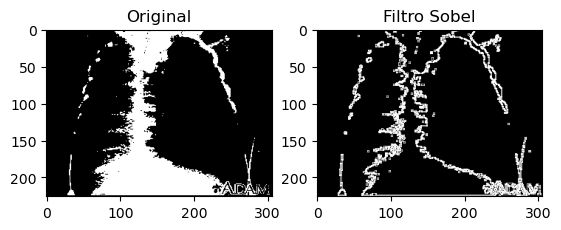

In [33]:
im = imageio.imread('RXTorax.jpg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)
hist = ndi.histogram(im, min=0, max=255, bins=256)
cdf = hist.cumsum() / hist.sum()
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
# Create bone mask
mask_bone = im_ecualizada >=199
# Apply Sobel filter along both axes
sobel_ax0 = ndi.sobel(mask_bone, axis=0)
sobel_ax1 = ndi.sobel(mask_bone, axis=1)
# Calculate edge magnitude
edges = np.sqrt(np.square(sobel_ax0) + np.square(sobel_ax1))
# Mostrar
30
fig, axes = plt.subplots(1,2)
axes[0].imshow(mask_bone, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(edges, cmap='gray'); axes[1].set_title('Filtro Sobel')
plt.show()

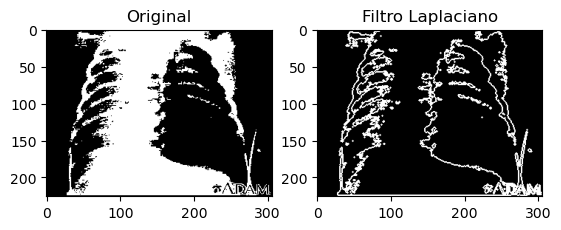

In [35]:
# Crear histograma y ecualizar
hist = ndi.histogram(im, min=0, max=255, bins=256)
cdf = hist.cumsum() / hist.sum()
im_ecualizada = (cdf[im] * 255).astype(np.uint8)

# Create bone mask
mask_bone = im_ecualizada >= 150

# Apply Laplace filter
laplacian = ndi.laplace(mask_bone)

# Mostrar
fig, axes = plt.subplots(1, 2)
axes[0].imshow(mask_bone, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(laplacian, cmap='gray')
axes[1].set_title('Filtro Laplaciano')
plt.show()